In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit
from google.colab import drive
from matplotlib.lines import Line2D

In [ ]:
TINY_SIZE = 6
SMALL_SIZE = 8
MEDIUM_SIZE = 10
BIGGER_SIZE = 12

Figure 2e: Half-life distribution plot for all PLATCOV simulated individuals

Import data

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
vd_df = pd.read_excel('./ViralDynamicsData_Publication.xlsx')

# Keep only treated individuals and sort for piecewise simulation
treated_df = vd_df[vd_df["treatment_cov"] == 1].copy()
treated_df = treated_df.sort_values(["ID", "time"])
# Load parameter tables
params_df_A1 = pd.read_csv("./estimatedIndividualParameters_A1.txt", sep=',')
params_df_A2 = pd.read_csv("./estimatedIndividualParameters_A2.txt", sep=',')
params_df_A3 = pd.read_csv("./estimatedIndividualParameters_A3.txt", sep=',')
params_df_A4T = pd.read_csv("./estimatedIndividualParameters_A4T.txt", sep=',')

In [ ]:

PK_CONSTANTS = {
   "A1": {"MolMass": 602.58, "Volume": 3690},
   "A2": {"MolMass": 442.32, "Volume": 30446.12},
   "A3": {"MolMass": 291.26, "Volume": 924.6},
   "A4T": {"MolMass": 531.2, "Volume": 1000000}
}

PD_PARAMS = {
   "Emax": 0.99,
   "Hill": 1,
   "c": 15,
   "k": 4,
   "F": 1_000_000
}

# Fixed PK Parameters
FIXED_PK = {
    "k12":22.525296,
    "k23":0.6,
    "kcl1":0.000864,
    "kcl2":9.6,
    "kcl3":6,
    "kcl4":1.0824,
    "k1pt":319.2,
    "k1tp":3.12,
    "k2pt":10.32,
    "k2tp":0.01296,
    "k3tp":0.036,
    "k3pt":1.08,
    "k34":6
}

In [ ]:

def viral_dynamic_model(t, y, target_cpt, params, dynamic_inputs):
  """
  Combined PK/PD and Viral Dynamics ODE system.
  """
  A1, A1T, A2, A2T, A3, A3T, A4T, T, R, E, I, V = y

  # Unpack dynamic input
  treatment = dynamic_inputs['treatment']

  # Unpack VD parameters
  beta = params['beta']
  pi = params['pi']
  rho = params['rho']
  phi = params['phi']
  delta = params['delta']
  m = params['m']
  tau = params['tau']
  IC50 = params['IC50']

  # --- PK Model ---
  ddt_A1 = FIXED_PK['k1tp']*A1T - (FIXED_PK['k1pt'] + FIXED_PK['k12'] + FIXED_PK['kcl1'])*A1

  ddt_A2 = FIXED_PK['k12']*A1 + FIXED_PK['k2tp']*A2T - (FIXED_PK['k2pt'] + FIXED_PK['kcl2'] + FIXED_PK['k23'])*A2

  ddt_A3 = FIXED_PK['k3tp']*A3T - (FIXED_PK['kcl3'] + FIXED_PK['k3pt'])*A3 + FIXED_PK['k23']*A2

  ddt_A1T = (FIXED_PK['k1pt']*A1 - FIXED_PK['k1tp']*A1T - FIXED_PK['k12']*A1T)

  ddt_A2T = (FIXED_PK['k2pt']*A2 + FIXED_PK['k12']*A1T - FIXED_PK['k23']*A2T - FIXED_PK['k2tp']*A2T)

  ddt_A3T = (-FIXED_PK['k3tp']*A3T + FIXED_PK['k23']*A2T + FIXED_PK['k3pt']*A3 - FIXED_PK['k34']*A3T)

  ddt_A4T = (FIXED_PK['k34']*A3T - FIXED_PK['kcl4']*A4T)

  # --- PD Effect (epsilon) ---
  # Calculate Concentration based on target compartment
  if target_cpt == "A1":
      Cc = A1 / (PK_CONSTANTS["A1"]["Volume"] * PK_CONSTANTS["A1"]["MolMass"])
  elif target_cpt == "A2":
      Cc = A2 / (PK_CONSTANTS["A2"]["Volume"] * PK_CONSTANTS["A2"]["MolMass"])
  elif target_cpt == "A3":
      Cc = A3 / (PK_CONSTANTS["A3"]["Volume"] * PK_CONSTANTS["A3"]["MolMass"])
  elif target_cpt == "A4T":
      Cc = A4T / (PK_CONSTANTS["A4T"]["Volume"] * PK_CONSTANTS["A4T"]["MolMass"])
  else:
      Cc = 0

  if treatment == 0:
      epsilon = 0
  else:
      if Cc <= 0:
          epsilon = 0
      else:
          epsilon = PD_PARAMS['Emax'] * (Cc**PD_PARAMS['Hill']) / ((Cc**PD_PARAMS['Hill']) + (IC50**PD_PARAMS['Hill']))

  # --- Viral Dynamics ---
  eps = m if t > tau else 0

  ddt_T = -beta * T * V - phi * I * T + rho * R
  ddt_R = phi * I * T - rho * R
  ddt_E = beta * T * V - PD_PARAMS['k'] * E
  ddt_I = PD_PARAMS['k'] * E - delta * I - eps * I

  if I >= 1:
      temp = pi * (1 - epsilon) * I - PD_PARAMS['c'] * V
  else:
      temp = -PD_PARAMS['c'] * V

  ddt_V = temp

  return [ddt_A1, ddt_A1T, ddt_A2, ddt_A2T, ddt_A3, ddt_A3T, ddt_A4T, ddt_T, ddt_R, ddt_E, ddt_I, ddt_V]

In [ ]:
# Linear Model for Curve Fitting
def linear_clearance_model(time, intercept, slope):
    return intercept + slope * time

In [ ]:

def extract_patient_clearance_metrics(patient_id, target_cpt, data_df, param_df):
   """
   Simulates the patient trajectory, matches simulated viral load to empirical
   sampling times, fits a linear regression, and computes half-life with 80% CI.
   """
   p_row = param_df[param_df['id'] == patient_id].iloc[0]
   params = {
       'beta': 10 ** p_row['log10beta_mode'], 'pi': 10 ** p_row['log10pi_mode'],
       'rho': 10 ** p_row['log10rho_mode'], 'phi': 10 ** p_row['log10phi_mode'],
       'delta': p_row['delta_mode'], 'm': p_row['m_mode'], 'tau': p_row['tau_mode'],
       'tzero': p_row['tzero_mode'], 'Vzero': p_row['Vzero_mode'], 'IC50': p_row['IC50_mode']
   }

   pt_data = data_df[data_df['ID'] == patient_id].sort_values(by='time').copy()
   treatment_arm = pt_data.iloc[0]['treatment']

   # y = [A1, A1T, A2, A2T, A3, A3T, A4T, T, R, E, I, V]
   y0 = [0, 0, 0, 0, 0, 0, 0, 1e7, 0, 0, 0, params['Vzero']]
   current_time = -params['tzero']

   first_record = pt_data.iloc[0]

   active_inputs = {
       'treatment': treatment_arm
   }

   t_out, V_out = [], []

   # Piecewise integration
   for idx, row in pt_data.iterrows():
       t_event = row['time']
       if t_event > current_time:
           t_eval = np.linspace(current_time, t_event, 50)
           if t_event not in t_eval: t_eval = np.append(t_eval, t_event)

           sol = solve_ivp(
               fun=viral_dynamic_model, t_span=(current_time, t_event), y0=y0,
               t_eval=np.sort(t_eval), args=(target_cpt, params, active_inputs),
               method='LSODA', max_step=0.1
           )
           t_out.append(sol.t)

           V_out.append(sol.y[11, :])
           y0 = sol.y[:, -1]
           current_time = t_event

       dose_mg = row['Amnt_mg']
       if pd.notna(dose_mg) and dose_mg > 0: y0[0] += dose_mg * PD_PARAMS['F']

       if pd.notna(row['treatment']): active_inputs['treatment'] = row['treatment']

   t_sim = np.concatenate(t_out)
   V_sim = np.concatenate(V_out)
   log10V_sim = np.maximum(np.log10(np.maximum(V_sim, 1e-12)), 0.5)

   # --- Linear Fitting Phase ---
   sampled_times = pt_data[pt_data['y'].notna()]['time'].values

   simulated_V_at_samples = np.interp(sampled_times, t_sim, log10V_sim)

   fit_mask = simulated_V_at_samples > 0.5
   t_fit = sampled_times[fit_mask]
   V_fit = simulated_V_at_samples[fit_mask]

   thalf, thalf_lower, thalf_upper = np.nan, np.nan, np.nan

   if len(t_fit) >= 3:
       try:
           popt, pcov = curve_fit(linear_clearance_model, t_fit, V_fit, p0=[6, -1])
           slope = popt[1]

           slope_err = np.sqrt(pcov[1, 1])

           z_80 = 1.28
           slope_lower = slope - (z_80 * slope_err)
           slope_upper = slope + (z_80 * slope_err)

           if slope < 0:
               thalf = (np.log10(0.5) / slope) * 24
               thalf_lower = (np.log10(0.5) / min(slope_lower, -1e-6)) * 24
               thalf_upper = (np.log10(0.5) / min(slope_upper, -1e-6)) * 24
       except RuntimeError:
           pass

   return {
       "ID": patient_id,
       "Treatment": "Remdesivir" if treatment_arm == 1 else "No study drug",
       "t_half": thalf,
       "t_half_lower": thalf_lower,
       "t_half_upper": thalf_upper
   }

In [ ]:
def generate_clearance_forest_plot(vd_df, param_df, target_cpt="A4T"):
    platcov_df = vd_df[vd_df['Study'] == 'Platcov'].copy()
    patient_ids = platcov_df['ID'].unique()

    results = []
    print(f"Calculating Viral Clearance Half-Lives for {len(patient_ids)} Platcov patients...")
    for pid in patient_ids:
        metrics = extract_patient_clearance_metrics(pid, target_cpt, platcov_df, param_df)
        if pd.notna(metrics['t_half']):
            results.append(metrics)

    df_results = pd.DataFrame(results)
    df_results = df_results.sort_values(by=['Treatment', 't_half'], ascending=[False, False]).reset_index(drop=True)

    df_trt = df_results[df_results['Treatment'] == 'Remdesivir']
    df_ctl = df_results[df_results['Treatment'] == 'No study drug']

    median_trt = df_trt['t_half'].median()
    median_ctl = df_ctl['t_half'].median()

    fig, ax = plt.subplots(figsize=(3.4, 1.7), dpi=300)

    y_positions = []
    vertical_step = 0.22
    current_y = len(df_results) * vertical_step + 0.6

    for idx, row in df_results.iterrows():
        if idx > 0 and row['Treatment'] != df_results.iloc[idx-1]['Treatment']:
            current_y -= 0.6

        y_positions.append(current_y)

        color = 'dimgray' if row['Treatment'] == 'Remdesivir' else 'limegreen'

        ax.hlines(
            y=current_y,
            xmin=row['t_half_lower'],
            xmax=row['t_half_upper'],
            color=color,
            linewidth=0.4,
            alpha=0.7
        )

        ax.plot(
            row['t_half'],
            current_y,
            marker='s',
            markersize=1.2,
            color=color
        )

        current_y -= vertical_step

    ax.axvline(x=median_trt, color='dimgray', linestyle='--', linewidth=0.8, zorder=0)
    ax.axvline(x=median_ctl, color='limegreen', linestyle='--', linewidth=0.8, zorder=0)

    ax.set_xlabel(
        r"Estimated Viral Clearance Half-life $t_{1/2}$ (hours)",
        fontsize=MEDIUM_SIZE
    )

    ax.set_xlim(0, 55)

    ax.tick_params(axis='x', labelsize=SMALL_SIZE)

    legend_elements = [
        Line2D([0], [0], marker='s', color='dimgray', label='Remdesivir',
               markersize=2, linewidth=0),
        Line2D([0], [0], marker='s', color='limegreen', label='No study drug',
               markersize=2, linewidth=0)
    ]

    ax.legend(
        handles=legend_elements,
        loc='lower right',
        frameon=True,
        edgecolor='black',
        fontsize=TINY_SIZE
    )

    ax.set_yticks([])
    ax.grid(axis='x', linestyle='--', alpha=0.3, linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)

    plt.tight_layout(pad=0.3)
    plt.show()

    print(f"Median Remdesivir t1/2: {median_trt:.2f} hours")
    print(f"Median Control t1/2:    {median_ctl:.2f} hours")

    return df_results

Calculating Viral Clearance Half-Lives for 162 Platcov patients...


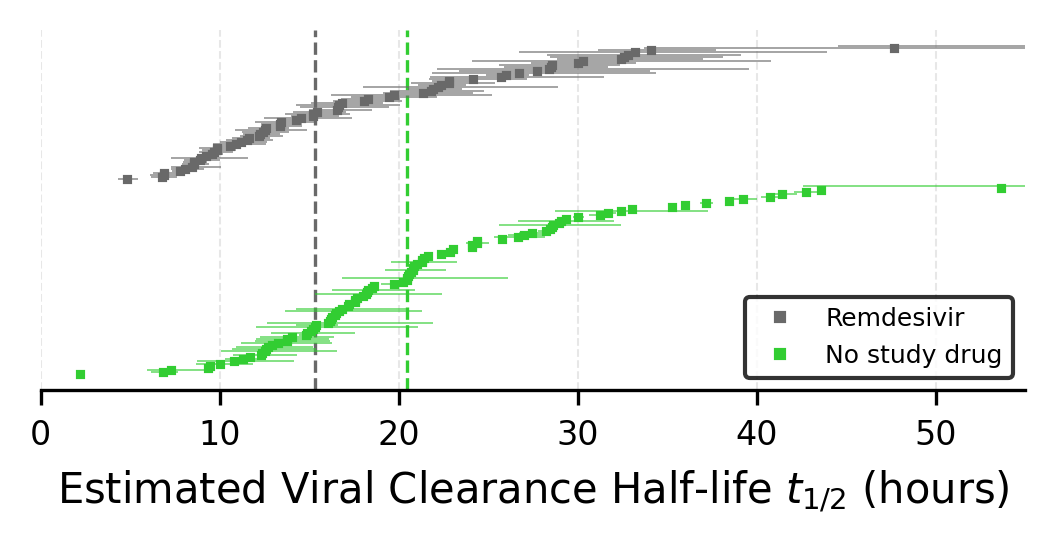

Median Remdesivir t1/2: 15.35 hours
Median Control t1/2:    20.48 hours


In [ ]:
# Execution
final_df = generate_clearance_forest_plot(vd_df, params_df_A4T, target_cpt="A4T")

Figure 2d: Average viral load reduction curves


In [ ]:

def simulate_patient(patient_id, target_cpt, data_df, param_df):
  """
  Simulates the VD model for a specific patient and a specific target compartment.
  """
  # 1. Extract Individual VD Parameters
  p_row = param_df[param_df['id'] == patient_id].iloc[0]

  params = {
      'beta': 10 ** p_row['log10beta_mode'],
      'pi': 10 ** p_row['log10pi_mode'],
      'rho': 10 ** p_row['log10rho_mode'],
      'phi': 10 ** p_row['log10phi_mode'],
      'delta': p_row['delta_mode'],
      'm': p_row['m_mode'],
      'tau': p_row['tau_mode'],
      'tzero': p_row['tzero_mode'],
      'Vzero': p_row['Vzero_mode'],
      'IC50': p_row['IC50_mode']
  }

  # 2. Extract Patient Data/Events
  pt_data = data_df[data_df['ID'] == patient_id].sort_values(by='time').copy()

  # Initial Conditions (at t = -tzero)
  y0 = [0, 0, 0, 0, 0, 0, 0, 1e7, 0, 0, 0, params['Vzero']]
  t_start = -params['tzero']

  t_out = []
  y_out = []

  current_time = t_start

  first_record = pt_data.iloc[0]
  active_inputs = {
      'treatment': first_record['treatment']
  }

  # 3. Piecewise Integration over Data Events
  for idx, row in pt_data.iterrows():
      t_event = row['time']

      if t_event > current_time:
          t_eval = np.linspace(current_time, t_event, max(50, int((t_event - current_time) * 100)))

          sol = solve_ivp(
              fun=viral_dynamic_model,
              t_span=(current_time, t_event),
              y0=y0,
              t_eval=t_eval,
              args=(target_cpt, params, active_inputs),
              method='LSODA',
              max_step=0.1
          )

          t_out.append(sol.t)
          y_out.append(sol.y)

          y0 = sol.y[:, -1]
          current_time = t_event

      dose_mg = row['Amnt_mg']
      if pd.notna(dose_mg) and dose_mg > 0:
          y0[0] += dose_mg * PD_PARAMS['F']

      active_inputs['treatment'] = row['treatment']

  t_final = current_time + 10
  t_eval = np.linspace(current_time, t_final, 500)
  sol = solve_ivp(
      fun=viral_dynamic_model,
      t_span=(current_time, t_final),
      y0=y0,
      t_eval=t_eval,
      args=(target_cpt, params, active_inputs),
      method='LSODA',
      max_step=0.1
  )
  t_out.append(sol.t)
  y_out.append(sol.y)

  t_sim = np.concatenate(t_out)
  y_sim = np.concatenate(y_out, axis=1)

  # Extract Viral Load and apply LLOQ logic
  V_sim = y_sim[11, :]
  V_sim = np.where(V_sim < 200, 100, V_sim)
  log10V_sim = np.log10(V_sim)

  return t_sim, log10V_sim

In [ ]:

def generate_platcov_viral_load_plot(vd_df, param_df, target_cpt="A4T"):
    plt.rcParams.update({
        'font.size': SMALL_SIZE,
        'axes.labelsize': MEDIUM_SIZE,
        'xtick.labelsize': SMALL_SIZE,
        'ytick.labelsize': SMALL_SIZE,
        'legend.fontsize': SMALL_SIZE
    })

    platcov_df = vd_df[vd_df['Study'] == 'Platcov'].copy()
    patient_ids = platcov_df['ID'].unique()

    target_days = np.array([0, 1, 2, 3, 4, 5, 6, 7])
    records = []

    for pid in patient_ids:
        pt_data = platcov_df[platcov_df['ID'] == pid]
        treatment_arm = pt_data.iloc[0]['treatment']

        if treatment_arm == 1:
            doses = pt_data[pt_data['Amnt_mg'] > 0]
            t_zero = doses['time'].min() if not doses.empty else pt_data['time'].min()
        else:
            t_zero = pt_data['time'].min()

        t_sim, log10V_sim = simulate_patient(pid, target_cpt, platcov_df, param_df)
        t_shifted = t_sim - t_zero

        log10V_daily = np.interp(target_days, t_shifted, log10V_sim,
                                left=np.nan, right=np.nan)

        for day, val in zip(target_days, log10V_daily):
            if not np.isnan(val):
                records.append({
                    'Patient_ID': pid,
                    'Treatment': treatment_arm,
                    'Day': day,
                    'log10V': val
                })

    df_daily = pd.DataFrame(records)

    n_treated = len(platcov_df[platcov_df['treatment'] == 1]['ID'].unique())
    n_control = len(platcov_df[platcov_df['treatment'] == 0]['ID'].unique())

    median_df = df_daily.groupby(['Day', 'Treatment'])['log10V'].median().reset_index()

    fig, ax = plt.subplots(figsize=(1.8, 2.5), dpi=300)

    colors = {0: 'limegreen', 1: 'dimgray'}
    labels = {
        0: f'Control)',
        1: f'Treatment)'
    }

    for trt in [0, 1]:
        group_data = df_daily[df_daily['Treatment'] == trt]
        jittered_days = group_data['Day'] + np.random.normal(0, 0.08, size=len(group_data))
        actual_V = 10**group_data['log10V']

        ax.scatter(
            jittered_days, actual_V,
            facecolors='none',
            edgecolors=colors[trt],
            alpha=0.25,
            s=8,
            linewidths=0.4,
            zorder=1
        )

    for trt in [0, 1]:
        med_data = median_df[median_df['Treatment'] == trt].sort_values('Day')
        actual_med_V = 10**med_data['log10V']

        ax.plot(
            med_data['Day'], actual_med_V,
            color=colors[trt],
            marker='s',
            markersize=3,
            linewidth=1.0,
            linestyle='--',
            label=labels[trt],
            zorder=3
        )

    ax.axhline(
        y=200,
        color='gray',
        linestyle='--',
        linewidth=0.8,
        alpha=0.7,
        label='LLOQ'
    )

    ax.set_yscale('log')
    ax.set_ylim(10**1, 10**8.5)
    ax.set_xlim(-0.5, 7.5)
    ax.set_xticks(target_days)

    ax.set_xlabel("Time (days)", fontsize=MEDIUM_SIZE)
    ax.set_ylabel("RNA copies/mL", fontsize=MEDIUM_SIZE)

    ax.grid(True, linestyle='--', alpha=0.4, linewidth=0.5)

    ax.legend(
        loc='upper right',
        frameon=True,
        edgecolor='black',
        fontsize=TINY_SIZE,
        borderpad=0.3,
        handlelength=1.2,
        fancybox=False
    )

    plt.tight_layout(pad=0.3)
    plt.show()

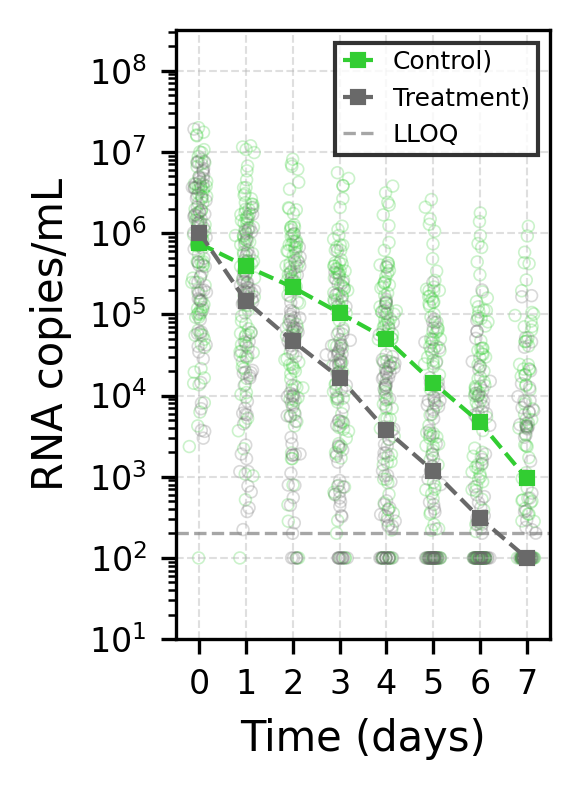

In [ ]:
generate_platcov_viral_load_plot(vd_df, params_df_A4T, target_cpt="A4T")